In [4]:
import os
import random
import shutil
from PIL import Image

# ============================================================
# 路径配置
# ============================================================
BG_DIR       = r"dataset/bg_pic"        # 背景图目录（20张）
YELLOW_DIR   = r"dataset/yellow"        # 小黄人 PNG（20个，含透明通道）
OUTPUT_DIR   = r"dataset/sample"        # 输出目录

IMG_SIZE     = 300                      # 统一图片尺寸
POS_PER_BG   = 8                        # 每张背景生成几张正样本
TRAIN_RATIO  = 0.8                      # 训练集比例
RANDOM_SEED  = 42

random.seed(RANDOM_SEED)


def save_yolo_label(txt_path, x1, y1, x2, y2, class_id=0):
    """
    将 bbox 坐标转为 YOLO 格式并保存到 .txt 文件。
    YOLO 格式: class_id cx cy w h （全部归一化到 0~1）
    """
    cx = (x1 + x2) / 2.0 / IMG_SIZE
    cy = (y1 + y2) / 2.0 / IMG_SIZE
    w  = (x2 - x1) / IMG_SIZE
    h  = (y2 - y1) / IMG_SIZE
    with open(txt_path, 'w') as f:
        f.write(f"{class_id} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}\n")


# ============================================================
# 收集文件列表
# ============================================================
bg_files = sorted(os.listdir(BG_DIR))
yellow_files = sorted(os.listdir(YELLOW_DIR))

print(f"背景图: {len(bg_files)} 张")
print(f"小黄人: {len(yellow_files)} 个")

# ============================================================
# 清空并重建输出目录
# ============================================================
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)

train_dir = os.path.join(OUTPUT_DIR, "train")
test_dir  = os.path.join(OUTPUT_DIR, "test")
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# ============================================================
# 生成数据集
# ============================================================
all_samples = []   # (filename, label, x1, y1, x2, y2, is_positive)

for bg_name in bg_files:
    if not bg_name.lower().endswith(('.jpg', '.jpeg', '.png')):
        continue

    bg_path = os.path.join(BG_DIR, bg_name)
    bg = Image.open(bg_path).convert("RGB")
    bg = bg.resize((IMG_SIZE, IMG_SIZE))
    stem = bg_name.rsplit('.', 1)[0]

    # ---- 负样本（纯背景，无小黄人） ----
    # 图片
    neg_name = f"{stem}.0.0.0.0.0.jpg"
    bg.save(os.path.join(train_dir, neg_name))
    # 标注（空文件，无目标）
    neg_txt = neg_name.rsplit('.', 1)[0] + '.txt'
    open(os.path.join(train_dir, neg_txt), 'w').close()
    all_samples.append((neg_name, 0, 0, 0, 0, 0, False))

    # ---- 正样本（每张背景生成多张） ----
    for pos_idx in range(POS_PER_BG):
        # 复制背景底图
        canvas = bg.copy()

        # 随机选一个小黄人
        yel_name = random.choice(yellow_files)
        yel_path = os.path.join(YELLOW_DIR, yel_name)
        yel = Image.open(yel_path)

        # 随机尺寸
        rand_w = random.randint(50, 170)
        yel_resized = yel.resize((rand_w, rand_w))

        # 随机位置（防越界）
        x1 = random.randint(0, IMG_SIZE - rand_w)
        y1 = random.randint(0, IMG_SIZE - rand_w)
        x2 = x1 + rand_w
        y2 = y1 + rand_w

        # 贴图（用 alpha 通道做蒙版）
        r, g, b, a = yel_resized.split()
        canvas.paste(yel_resized, (x1, y1), mask=a)

        # 随机水平翻转（数据增强）
        if random.random() > 0.5:
            canvas = canvas.transpose(Image.FLIP_LEFT_RIGHT)
            x1, x2 = IMG_SIZE - x2, IMG_SIZE - x1

        # 保存图片
        pos_name = f"{stem}.p{pos_idx}.{x1}.{y1}.{x2}.{y2}.1.jpg"
        canvas.save(os.path.join(train_dir, pos_name))

        # 保存 YOLO 标注文件
        pos_txt = pos_name.rsplit('.', 1)[0] + '.txt'
        save_yolo_label(os.path.join(train_dir, pos_txt), x1, y1, x2, y2, class_id=0)

        all_samples.append((pos_name, 1, x1, y1, x2, y2, True))

# ============================================================
# 划分 train / test（保持目录结构，移动文件）
# ============================================================
random.shuffle(all_samples)
split_idx = int(len(all_samples) * TRAIN_RATIO)

for i, (fname, label, x1, y1, x2, y2, is_pos) in enumerate(all_samples):
    src_img = os.path.join(train_dir, fname)
    if not os.path.exists(src_img):
        continue

    if i >= split_idx:
        # 移动图片
        dst_img = os.path.join(test_dir, fname)
        shutil.move(src_img, dst_img)

        # 同时移动对应的 .txt 标注文件
        txt_name = fname.rsplit('.', 1)[0] + '.txt'
        src_txt = os.path.join(train_dir, txt_name)
        if os.path.exists(src_txt):
            shutil.move(src_txt, os.path.join(test_dir, txt_name))

# ============================================================
# 统计
# ============================================================
def count_stats(data_dir):
    imgs = [f for f in os.listdir(data_dir) if f.endswith('.jpg')]
    pos = sum(1 for f in imgs if f.endswith('.1.jpg'))
    neg = len(imgs) - pos
    return len(imgs), pos, neg

total, pos, neg = count_stats(train_dir)
print(f"\n训练集: {total} 张 (正样本 {pos}, 负样本 {neg})")
total_t, pos_t, neg_t = count_stats(test_dir)
print(f"测试集: {total_t} 张 (正样本 {pos_t}, 负样本 {neg_t})")
print(f"总计:   {total + total_t} 张")
print("\n✅ 数据集制作完成！")


背景图: 20 张
小黄人: 20 个

训练集: 144 张 (正样本 129, 负样本 15)
测试集: 36 张 (正样本 31, 负样本 5)
总计:   180 张

✅ 数据集制作完成！


In [5]:
import torch
from PIL import Image, ImageDraw
import numpy as np
from torch.utils.data import Dataset, DataLoader
import os

root_path = r"dataset/sample"

class MyDataset(Dataset):
    def __init__(self, in_train=True):
        super().__init__()
        self.train = 'train' if in_train else 'test'
        self.train_path = os.path.join(root_path, self.train)
        # 只保留 .jpg，过滤掉 .txt 标注文件
        self.data = [f for f in os.listdir(self.train_path) if f.endswith('.jpg')]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        name_org = self.data[index]
        parts = name_org.split(".")

        img_path = os.path.join(self.train_path, name_org)
        img_data = Image.open(img_path).convert("RGB")
        img_data_np = np.array(img_data)
        img_data_tensor = torch.from_numpy(img_data_np).float()
        img_data_tensor = img_data_tensor / 255.0
        img_data_tensor = torch.permute(img_data_tensor, (2, 0, 1))

        # 文件名格式（从后往前解析，兼容正负样本）：
        # 正: {stem}.p{idx}.{x1}.{y1}.{x2}.{y2}.{cls}.jpg
        # 负: {stem}.0.0.0.0.0.jpg
        x1, y1, x2, y2 = float(parts[-6]), float(parts[-5]), float(parts[-4]), float(parts[-3])
        cls_ = torch.tensor(float(parts[-2]))

        point_nor = torch.tensor([x1, y1, x2, y2]) / 300.0

        return img_data_tensor, point_nor, cls_

if __name__ == "__main__":
    dataset = MyDataset()
    print(f"数据集大小: {len(dataset)}")
    img_data, pts, cls_ = dataset[1]
    print(f"图片张量形状: {img_data.shape}")
    print(f"归一化坐标: {pts}")
    print(f"类别标签: {cls_}")

数据集大小: 144
图片张量形状: torch.Size([3, 300, 300])
归一化坐标: tensor([0.6300, 0.2333, 0.8067, 0.4100])
类别标签: 1.0


In [6]:
import torch
from torch import nn

class Net(nn.Module):
    """单目标检测网络 — 全连接输出版本（老师提供的）"""

    def __init__(self):
        super().__init__()

        # 特征提取器：8 层卷积 + 池化的堆叠
        self.layers = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),

            nn.Conv2d(64, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),

            nn.Conv2d(128, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2),

            nn.Conv2d(256, 512, 3, padding=1, bias=False),
            nn.BatchNorm2d(512), nn.ReLU(), nn.MaxPool2d(2),

            nn.Conv2d(512, 512, 3, padding=1, bias=False),
            nn.BatchNorm2d(512), nn.ReLU(), nn.MaxPool2d(2),

            nn.Conv2d(512, 512, 3, padding=1, bias=False),
            nn.BatchNorm2d(512), nn.ReLU(), nn.MaxPool2d(2),
        )

        # 耦合输出头：统一输出 5 个值 [x1, y1, x2, y2, conf]，全部 sigmoid 到 [0,1]
        self.out_layer = nn.Sequential(
            nn.Linear(512 * 1 * 1, 5),
            nn.Sigmoid()
        )

    def forward(self, x):
        # (N, 3, 300, 300) → (N, 512, 1, 1)
        x = self.layers(x)

        # (N, 512, 1, 1) → (N, 512)
        x = x.reshape(x.shape[0], -1)

        # (N, 512) → (N, 5)
        out = self.out_layer(x)
        return out


if __name__ == "__main__":
    model = Net()
    dummy = torch.randn(4, 3, 300, 300)
    out = model(dummy)
    print(f"输出形状: {out.shape}  (B, 5)")
    print(f"总参数量: {sum(p.numel() for p in model.parameters())/1e6:.2f}M")

输出形状: torch.Size([4, 5])  (B, 5)
总参数量: 6.46M


## 拓展②：全卷积版网络 (FullyConvNet)

与上面的全连接版对比：

| | 全连接版 (Net) | 全卷积版 (FullyConvNet) |
|---|---|---|
| 输出方式 | `Flatten → Linear → 5` | `Conv2d(1×1) → 5` 或 `Grid 预测` |
| 空间信息 | 池化到 1×1，丢失空间位置 | 保留 Grid 特征图，**空间位置感知** |
| 参数量 | ~9.5M（线性层大） | 更小更高效 |
| 本质 | 用 FC 强行"记住"位置 | 用卷积在空间上"感知"位置 |

下面实现两个版本的全卷积网络，对比看看差异。

In [7]:
class FullyConvNet(nn.Module):
    """
    全卷积版检测网络 — Version A（简易替换版）
    
    和 Net 完全相同的 backbone，但把最后的 Linear 换成了 1×1 Conv。
    输出格式也是 (B, 5)，可以直接套用上面的训练代码。
    
    本质变化: Linear(512, 5)  →  Conv2d(512, 5, 1) + AdaptiveAvgPool
    """
    def __init__(self):
        super().__init__()

        # ---- 特征提取器（和 Net 一模一样） ----
        self.layers = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),

            nn.Conv2d(64, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),

            nn.Conv2d(128, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2),

            nn.Conv2d(256, 512, 3, padding=1, bias=False),
            nn.BatchNorm2d(512), nn.ReLU(), nn.MaxPool2d(2),

            nn.Conv2d(512, 512, 3, padding=1, bias=False),
            nn.BatchNorm2d(512), nn.ReLU(), nn.MaxPool2d(2),

            nn.Conv2d(512, 512, 3, padding=1, bias=False),
            nn.BatchNorm2d(512), nn.ReLU(), nn.MaxPool2d(2),  # → (512, 1, 1)
        )

        # ---- 全卷积输出头（替代 Linear） ----
        # 1×1 conv + Global Average Pooling = 全卷积版 Linear
        self.out_conv = nn.Sequential(
            nn.Conv2d(512, 5, kernel_size=1),   # (B, 5, 1, 1)
            nn.Sigmoid()
        )

    def forward(self, x):
        # (B, 3, 300, 300) → (B, 512, 1, 1)
        x = self.layers(x)
        # (B, 512, 1, 1) → (B, 5, 1, 1) → (B, 5)
        out = self.out_conv(x)
        return out.squeeze(-1).squeeze(-1)   # 去掉 H,W 维度


class FullyConvNetV2(nn.Module):
    """
    全卷积版检测网络 — Version B（真正保留空间版）
    
    和 Net 的关键区别：
    - 少做几次 Pooling，保留 Grid 特征图（例如 9×9）
    - 每个 Grid Cell 都独立输出 5 个值 [x1,y1,x2,y2,conf]
    - 推理时取 conf 最高的 cell 作为最终检测结果
    - 真正的"全卷积"——每个位置独立感知
    """
    def __init__(self, grid_size=9):
        super().__init__()
        self.grid_size = grid_size

        # ---- 特征提取器（少 Pooling，保留 9×9 空间） ----
        # 输入 (3, 300, 300)
        self.backbone = nn.Sequential(
            # 3,300 → 64,150
            nn.Conv2d(3, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),

            # 64,150 → 64,75
            nn.Conv2d(64, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),

            # 64,75 → 128,37
            nn.Conv2d(64, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),

            # 128,37 → 256,18
            nn.Conv2d(128, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2),

            # 256,18 → 512,9
            nn.Conv2d(256, 512, 3, padding=1, bias=False),
            nn.BatchNorm2d(512), nn.ReLU(), nn.MaxPool2d(2),
        )  # → (512, 9, 9)

        # ---- 检测头：额外卷积 + 1×1 输出 ----
        self.head = nn.Sequential(
            nn.Conv2d(512, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(),

            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(),

            # 输出层：每个 grid cell 预测 5 个值
            nn.Conv2d(256, 5, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        """
        输入: (B, 3, 300, 300)
        输出: (B, 5, G, G)  其中 G = grid_size = 9
             - 每个 grid cell 预测 [x1, y1, x2, y2, conf]
             - 所有值都在 [0,1] 范围
        """
        feat = self.backbone(x)      # (B, 512, 9, 9)
        out = self.head(feat)        # (B, 5, 9, 9)
        return out

    def decode_prediction(self, out, img_size=300):
        """
        从网络输出解码最终检测结果。
        
        参数:
            out: (B, 5, G, G) 网络原始输出
            img_size: 原图尺寸（用于反归一化）
        
        返回:
            bboxes: (B, 4)  最终预测框 [x1,y1,x2,y2]（像素坐标）
            confs:  (B,)    对应置信度
        """
        B, _, G, _ = out.shape
        # 找每个 batch 中 conf 最高的 grid cell
        confs = out[:, 4, :, :]                        # (B, G, G)
        conf_flat = confs.view(B, -1)                  # (B, G*G)
        best_idx = conf_flat.argmax(dim=1)             # (B,)

        # 将 flat index 转换回 grid 坐标
        best_row = best_idx // G
        best_col = best_idx % G

        batch_indices = torch.arange(B, device=out.device)
        # 取出最佳 cell 的 bbox 预测
        x1_norm = out[batch_indices, 0, best_row, best_col]   # (B,)
        y1_norm = out[batch_indices, 1, best_row, best_col]
        x2_norm = out[batch_indices, 2, best_row, best_col]
        y2_norm = out[batch_indices, 3, best_row, best_col]
        best_conf = confs[batch_indices, best_row, best_col]

        # 反归一化 → 像素坐标
        bboxes = torch.stack([
            x1_norm * img_size,
            y1_norm * img_size,
            x2_norm * img_size,
            y2_norm * img_size,
        ], dim=1)  # (B, 4)

        return bboxes, best_conf


# ========== 快速验证 ==========
if __name__ == "__main__":
    dummy = torch.randn(4, 3, 300, 300)

    # Version A
    model_a = FullyConvNet()
    out_a = model_a(dummy)
    print(f"FullyConvNet (A) 输出形状: {out_a.shape}  ← 兼容 (B,5)")
    print(f" 参数量: {sum(p.numel() for p in model_a.parameters())/1e6:.2f}M")

    # Version B
    model_b = FullyConvNetV2(grid_size=9)
    out_b = model_b(dummy)
    print(f"\nFullyConvNetV2 (B) 输出形状: {out_b.shape}  ← (B,5,G,G)")
    print(f" 参数量: {sum(p.numel() for p in model_b.parameters())/1e6:.2f}M")

    # 验证 B 的解码
    bboxes, confs = model_b.decode_prediction(out_b)
    print(f"\nV2 解码结果:")
    print(f"  最终框坐标: {bboxes}")
    print(f"  最高置信度: {confs}")


FullyConvNet (A) 输出形状: torch.Size([4, 5])  ← 兼容 (B,5)
 参数量: 6.46M

FullyConvNetV2 (B) 输出形状: torch.Size([4, 5, 9, 9])  ← (B,5,G,G)
 参数量: 3.36M

V2 解码结果:
  最终框坐标: tensor([[190.7045, 157.4762, 170.2146, 112.0413],
        [142.1864, 140.8953, 175.5753, 133.3441],
        [193.1372, 185.7544, 160.9724, 121.1853],
        [209.3410, 198.0185, 138.7293, 104.7354]], grad_fn=<StackBackward0>)
  最高置信度: tensor([0.7691, 0.7571, 0.7104, 0.7782], grad_fn=<IndexBackward0>)


In [8]:
# MyDataset 和 Net 已在前面单元格定义
from torch.utils.data import DataLoader
import torch.optim as optim

# ========== 超参数 ==========
BATCH_SIZE = 32
EPOCHS = 100
LR = 1e-3
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"使用设备: {DEVICE}")

# ========== 数据加载 ==========
train_dataset = MyDataset(in_train=True)
test_dataset  = MyDataset(in_train=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"训练集: {len(train_dataset)} 张, 测试集: {len(test_dataset)} 张")

# ========== 模型初始化 ==========
model = Net().to(DEVICE)
print(f"模型参数量: {sum(p.numel() for p in model.parameters())/1e6:.2f}M")

# ========== 损失函数 ==========
# 注意：老师网络的 conf 已经过 sigmoid，用 BCELoss
cls_loss_fn = nn.BCELoss()       # 分类：二分类交叉熵（输入已 sigmoid）
reg_loss_fn = nn.MSELoss()       # 回归：均方误差

# ========== 优化器 ==========
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# ========== 训练循环 ==========
best_loss = float('inf')

for epoch in range(EPOCHS):
    # ---- 训练 ----
    model.train()
    total_cls_loss = 0.0
    total_reg_loss = 0.0
    total_loss = 0.0

    for images, bboxes, labels in train_loader:
        images = images.to(DEVICE)          # (B, 3, 300, 300)
        bboxes = bboxes.to(DEVICE)          # (B, 4)  归一化坐标
        labels = labels.to(DEVICE)          # (B,)    0/1

        optimizer.zero_grad()

        out = model(images)                 # (B, 5)  [x1,y1,x2,y2,conf]
        bbox_preds = out[:, :4]             # (B, 4)
        conf_preds = out[:, 4]              # (B,)

        # ---- 分类损失（所有样本都参与） ----
        loss_cls = cls_loss_fn(conf_preds, labels)

        # ---- 回归损失（只计算正样本） ----
        pos_mask = (labels == 1)                # (B,) bool
        if pos_mask.any():
            loss_reg = reg_loss_fn(bbox_preds[pos_mask], bboxes[pos_mask])
        else:
            loss_reg = torch.tensor(0.0, device=DEVICE)

        # ---- 总损失 ----
        loss = loss_cls + loss_reg
        loss.backward()
        optimizer.step()

        total_cls_loss += loss_cls.item()
        if isinstance(loss_reg, torch.Tensor) and loss_reg.item() > 0:
            total_reg_loss += loss_reg.item()
        total_loss += loss.item()

    scheduler.step()

    avg_cls = total_cls_loss / len(train_loader)
    avg_reg = total_reg_loss / len(train_loader)
    avg_loss = total_loss / len(train_loader)

    # ---- 测试 ----
    model.eval()
    test_cls_loss = 0.0
    test_reg_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, bboxes, labels in test_loader:
            images = images.to(DEVICE)
            bboxes = bboxes.to(DEVICE)
            labels = labels.to(DEVICE)

            out = model(images)
            bbox_preds = out[:, :4]
            conf_preds = out[:, 4]

            # 分类损失
            loss_cls = cls_loss_fn(conf_preds, labels)
            test_cls_loss += loss_cls.item()

            # 回归损失（正样本）
            pos_mask = (labels == 1)
            if pos_mask.any():
                loss_reg = reg_loss_fn(bbox_preds[pos_mask], bboxes[pos_mask])
                test_reg_loss += loss_reg.item()

            # 分类准确率
            preds = (conf_preds > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_test_cls = test_cls_loss / len(test_loader)
    avg_test_reg = test_reg_loss / len(test_loader)
    acc = 100.0 * correct / total

    print(f"Epoch {epoch+1:3d}/{EPOCHS} | "
          f"Train: {avg_loss:.4f}(cls={avg_cls:.4f}+reg={avg_reg:.4f}) | "
          f"Test: cls={avg_test_cls:.4f} reg={avg_test_reg:.4f} | Acc: {acc:.2f}%")

    # 保存最佳模型
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(), './minion_detector_best.pth')

print(f"\n✅ 训练完成！最佳损失: {best_loss:.4f}")
print(f"模型已保存至: ./minion_detector_best.pth")

使用设备: cuda
训练集: 144 张, 测试集: 36 张
模型参数量: 6.46M
Epoch   1/100 | Train: 0.3940(cls=0.3439+reg=0.0502) | Test: cls=0.7198 reg=0.0511 | Acc: 86.11%
Epoch   2/100 | Train: 0.1824(cls=0.1694+reg=0.0131) | Test: cls=0.8224 reg=0.0555 | Acc: 13.89%
Epoch   3/100 | Train: 0.1114(cls=0.1013+reg=0.0100) | Test: cls=0.9307 reg=0.0542 | Acc: 13.89%
Epoch   4/100 | Train: 0.0694(cls=0.0609+reg=0.0086) | Test: cls=0.9424 reg=0.0570 | Acc: 13.89%
Epoch   5/100 | Train: 0.0519(cls=0.0445+reg=0.0074) | Test: cls=1.1217 reg=0.0573 | Acc: 13.89%
Epoch   6/100 | Train: 0.0324(cls=0.0259+reg=0.0065) | Test: cls=1.3521 reg=0.0555 | Acc: 13.89%
Epoch   7/100 | Train: 0.0258(cls=0.0198+reg=0.0060) | Test: cls=1.4816 reg=0.0557 | Acc: 13.89%
Epoch   8/100 | Train: 0.0174(cls=0.0107+reg=0.0067) | Test: cls=1.3185 reg=0.0459 | Acc: 19.44%
Epoch   9/100 | Train: 0.0131(cls=0.0071+reg=0.0059) | Test: cls=0.8215 reg=0.0307 | Acc: 55.56%
Epoch  10/100 | Train: 0.0124(cls=0.0070+reg=0.0054) | Test: cls=0.4726 reg=0.021

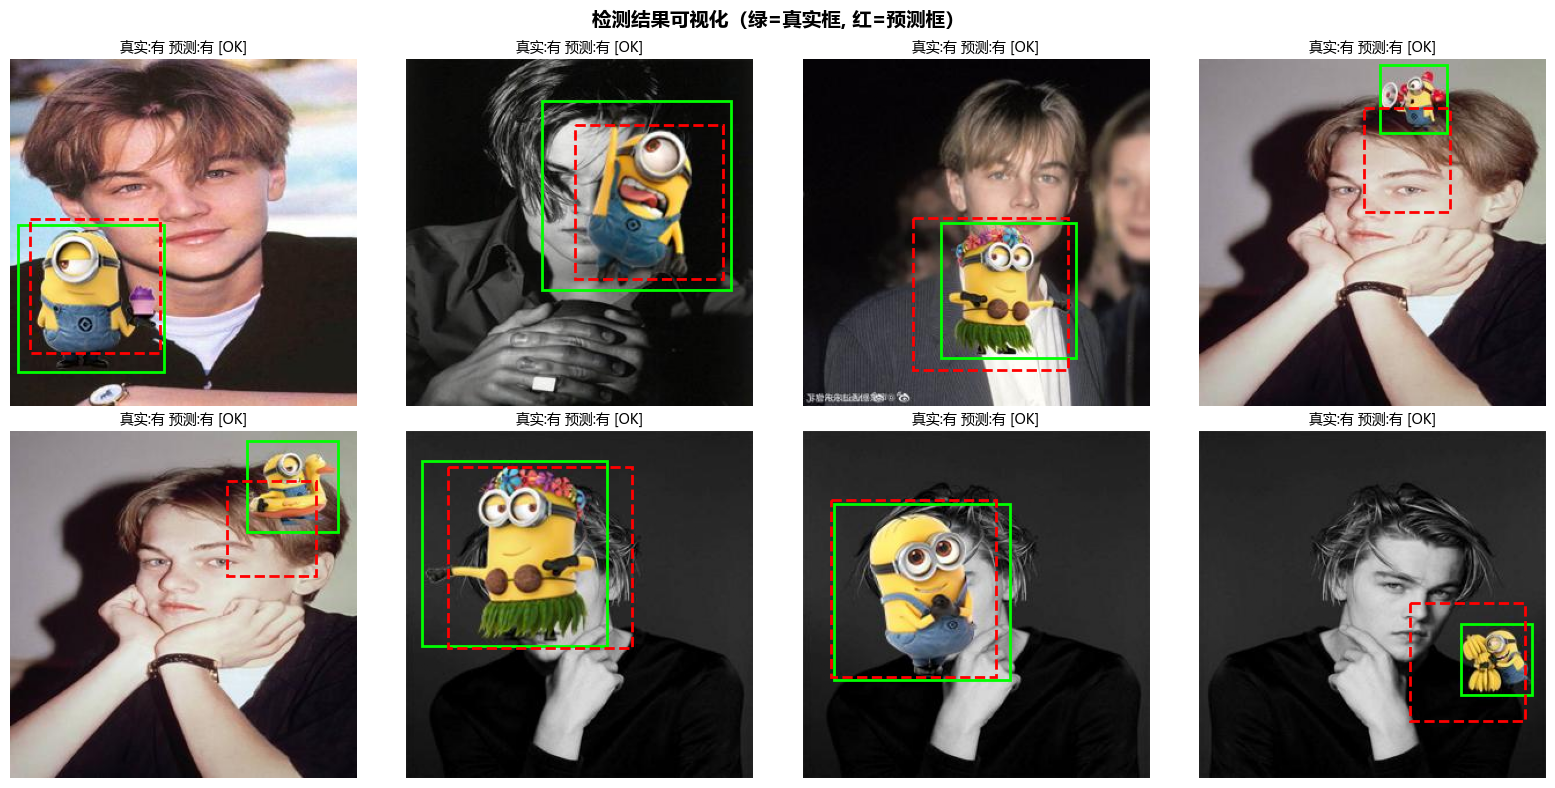

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ========== 加载最佳模型 ==========
model.load_state_dict(torch.load('./minion_detector_best.pth', weights_only=True))
model.eval()

# ========== 取一批测试集图片 ==========
dataiter = iter(test_loader)
images, bboxes, labels = next(dataiter)
images, bboxes, labels = images.to(DEVICE), bboxes.to(DEVICE), labels.to(DEVICE)

# ========== 推理 ==========
with torch.no_grad():
    out = model(images)                          # (B, 5)
    bbox_preds = out[:, :4]                      # (B, 4)
    conf_preds = out[:, 4]                       # (B,)
    pred_cls = (conf_preds > 0.5).float()
    pred_bbox = bbox_preds.cpu().numpy() * 300   # 反归一化到像素坐标
    true_bbox = bboxes.cpu().numpy() * 300

# ========== 可视化 ==========
n_show = min(8, len(images))
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(n_show):
    img = images[i].cpu().numpy().transpose((1, 2, 0))
    img = np.clip(img, 0, 1)

    axes[i].imshow(img)
    axes[i].axis('off')

    # --- 真实框（绿色） ---
    if labels[i].item() == 1:
        x1, y1, x2, y2 = true_bbox[i]
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor='lime', facecolor='none', linestyle='-'
        )
        axes[i].add_patch(rect)

    # --- 预测框（红色） ---
    if pred_cls[i].item() == 1:
        x1, y1, x2, y2 = pred_bbox[i]
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor='red', facecolor='none', linestyle='--'
        )
        axes[i].add_patch(rect)

    # 标题
    true_label = "有" if labels[i].item() == 1 else "无"
    pred_label = "有" if pred_cls[i].item() == 1 else "无"
    ok = "[OK]" if labels[i].item() == pred_cls[i].item() else "[XX]"
    axes[i].set_title(f"真实:{true_label} 预测:{pred_label} {ok}", fontsize=10)

plt.suptitle('检测结果可视化（绿=真实框, 红=预测框）', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

📊 IoU（交并比）评估结果
正样本总数: 29 张

IoU 统计:
  平均 IoU:  0.6190
  最高 IoU:  0.8703
  最低 IoU:  0.1395
  中位数 IoU: 0.6473
  IoU >= 0.3:  93.1%
  IoU >= 0.5:  79.3%
  IoU >= 0.7:  37.9%


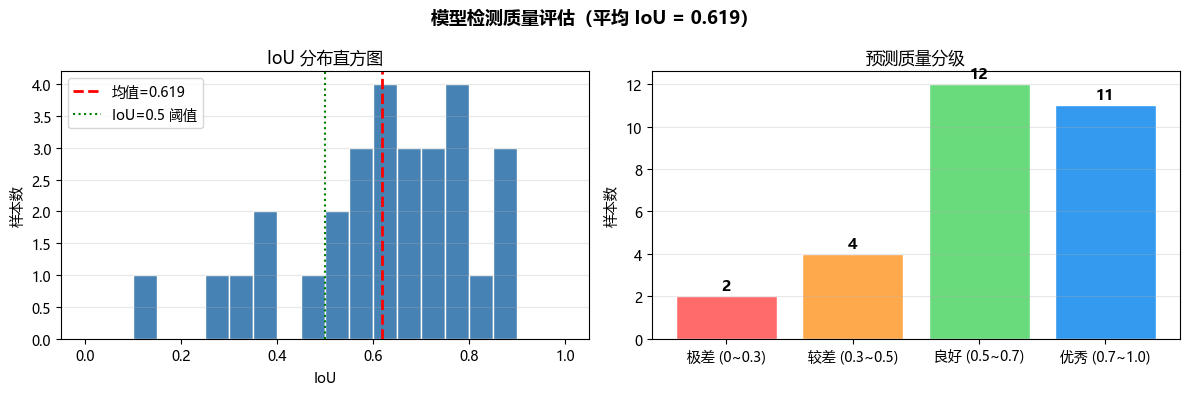


📉 IoU 最差的样本: IoU = 0.1395
📈 IoU 最好的样本: IoU = 0.8703


In [11]:
# ============================================================
# 计算 IoU（交并比）评估预测框质量
# IoU = 红框 ∩ 绿框 / 红框 ∪ 绿框
# 只对正样本（有小黄人）计算，负样本没有绿框
# ============================================================

def compute_iou(box1, box2):
    """
    计算两个框的 IoU。
    
    参数:
        box1, box2: [x1, y1, x2, y2]（像素坐标）
    返回:
        iou 标量
    """
    x1_inter = max(box1[0], box2[0])
    y1_inter = max(box1[1], box2[1])
    x2_inter = min(box1[2], box2[2])
    y2_inter = min(box1[3], box2[3])

    inter_w = max(0.0, x2_inter - x1_inter)
    inter_h = max(0.0, y2_inter - y1_inter)
    inter_area = inter_w * inter_h

    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union_area = area1 + area2 - inter_area

    if union_area <= 0:
        return 0.0
    return inter_area / union_area


# ========== 对当前 batch 逐张计算 IoU ==========
ious = []
valid_count = 0

for i in range(len(labels)):
    gt_label = labels[i].item()
    pred_label = pred_cls[i].item()

    if gt_label == 1:
        # 有绿框 → 计算 IoU
        gt_box = true_bbox[i]       # (4,) 像素坐标
        if pred_label == 1:
            # 预测也有框 → 正常算 IoU
            pred_box = pred_bbox[i]
            iou = compute_iou(gt_box, pred_box)
        else:
            # 漏检（预测无框）→ IoU = 0
            iou = 0.0
        ious.append(iou)
        valid_count += 1
    # 负样本（gt_label == 0）跳过，没有绿框

# ========== 统计结果 ==========
ious = np.array(ious)

print("=" * 60)
print("📊 IoU（交并比）评估结果")
print("=" * 60)
print(f"正样本总数: {valid_count} 张")

if len(ious) > 0:
    print(f"\nIoU 统计:")
    print(f"  平均 IoU:  {ious.mean():.4f}")
    print(f"  最高 IoU:  {ious.max():.4f}")
    print(f"  最低 IoU:  {ious.min():.4f}")
    print(f"  中位数 IoU: {np.median(ious):.4f}")

    # 按阈值统计
    for thresh in [0.3, 0.5, 0.7]:
        ratio = (ious >= thresh).mean()
        print(f"  IoU >= {thresh}:  {ratio*100:.1f}%")

    # IoU 分布直方图
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # 直方图
    axes[0].hist(ious, bins=20, range=(0, 1), color='steelblue', edgecolor='white')
    axes[0].axvline(ious.mean(), color='red', linestyle='--', linewidth=2, label=f'均值={ious.mean():.3f}')
    axes[0].axvline(0.5, color='green', linestyle=':', linewidth=1.5, label='IoU=0.5 阈值')
    axes[0].set_xlabel('IoU')
    axes[0].set_ylabel('样本数')
    axes[0].set_title('IoU 分布直方图')
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.3)

    # 条形图：按好坏分级
    levels = ['极差 (0~0.3)', '较差 (0.3~0.5)', '良好 (0.5~0.7)', '优秀 (0.7~1.0)']
    counts = [
        (ious < 0.3).sum(),
        ((ious >= 0.3) & (ious < 0.5)).sum(),
        ((ious >= 0.5) & (ious < 0.7)).sum(),
        (ious >= 0.7).sum(),
    ]
    colors_bar = ['#ff6b6b', '#ffa94d', '#69db7c', '#339af0']
    bars = axes[1].bar(levels, counts, color=colors_bar, edgecolor='white')
    # 在柱子上标数字
    for bar, count in zip(bars, counts):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     str(count), ha='center', fontsize=11, fontweight='bold')
    axes[1].set_ylabel('样本数')
    axes[1].set_title('预测质量分级')
    axes[1].grid(axis='y', alpha=0.3)

    plt.suptitle(f'模型检测质量评估（平均 IoU = {ious.mean():.3f}）', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # 打印几个最差和最好的例子
    worst_idx = ious.argmin()
    best_idx = ious.argmax()
    print(f"\n📉 IoU 最差的样本: IoU = {ious[worst_idx]:.4f}")
    print(f"📈 IoU 最好的样本: IoU = {ious[best_idx]:.4f}")

else:
    print("⚠️ 该 batch 中没有正样本，无法计算 IoU")


推理流程演示: 原图 → 预处理 → 网络 → 反归一化 → 画框
图片: 1.p3.6.143.133.270.1.jpg
原始图片尺寸: (300, 300, 3)  (H, W, C), 值范围 0-255

[Step 1] 除以 255 归一化: [0.000, 1.000]
[Step 2] 调整维度 (C,H,W): torch.Size([3, 300, 300])
[Step 3] 加 batch 维度 → 移到 cuda:0: torch.Size([1, 3, 300, 300])

[Step 4] 网络原始输出:
  归一化坐标 [x1,y1,x2,y2]: [0.05477569 0.46044055 0.43127882 0.84662116]
  置信度 conf: 1.0000  → 有小黄人 ✓

[Step 5] 反归一化 → 原图像素坐标:
  公式: pixel = norm_coord × 图片尺寸
  x1 = 0.0548 × 300 = 16
  y1 = 0.4604 × 300 = 138
  x2 = 0.4313 × 300 = 129
  y2 = 0.8466 × 300 = 253

[验证] 文件名中的真实坐标: (6.0, 143.0, 133.0, 270.0)


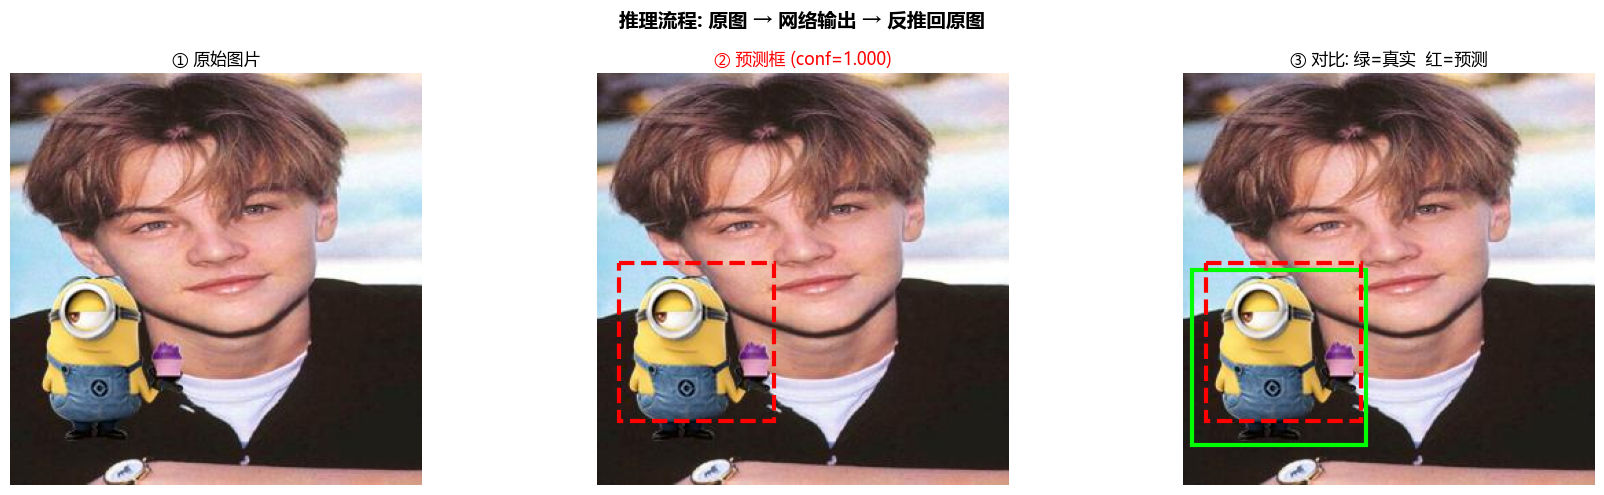


✅ 推理完成！以上就是完整的: 原图 → 预处理 → 推理 → 反归一化 → 画框 流程


In [10]:
# ============================================================
# 推理演示：网络输出 → 反推回原图画框
# 流程: 原图 → 预处理 → 网络推理 → 反归一化 → 画框
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np
import torch

# ========== 1. 加载模型 ==========
device = next(model.parameters()).device   # 获取模型所在设备
model.load_state_dict(torch.load('./minion_detector_best.pth', weights_only=True))
model.eval()

# ========== 2. 从测试集中取一张原图 ==========
# 取一张正样本（有小黄人的）
test_path = r"dataset/sample/test"
test_files = [f for f in os.listdir(test_path) if f.endswith('.1.jpg')]
img_name = test_files[0]                     # 选第一张正样本
img_path = os.path.join(test_path, img_name)

# 读取原图（PIL 格式，未归一化）
img_pil = Image.open(img_path).convert("RGB")
img_np = np.array(img_pil)                   # (H, W, 3), 0-255

print("=" * 60)
print("推理流程演示: 原图 → 预处理 → 网络 → 反归一化 → 画框")
print("=" * 60)
print(f"图片: {img_name}")
print(f"原始图片尺寸: {img_np.shape}  (H, W, C), 值范围 0-255")

# ========== 3. 预处理（跟训练时完全一致） ==========
# 3.1 归一化到 [0,1]
img_tensor = torch.from_numpy(img_np).float() / 255.0
print(f"\n[Step 1] 除以 255 归一化: [{img_tensor.min():.3f}, {img_tensor.max():.3f}]")

# 3.2 调整维度: (H,W,C) → (C,H,W)
img_tensor = torch.permute(img_tensor, (2, 0, 1))
print(f"[Step 2] 调整维度 (C,H,W): {img_tensor.shape}")

# 3.3 加 batch 维度: (C,H,W) → (1,C,H,W) → 移到模型所在设备
img_tensor = img_tensor.unsqueeze(0).to(device)
print(f"[Step 3] 加 batch 维度 → 移到 {device}: {img_tensor.shape}")

# ========== 4. 网络推理 ==========
with torch.no_grad():
    out = model(img_tensor)                  # (1, 5)
    bbox_norm = out[0, :4].cpu().numpy()     # [x1, y1, x2, y2] 归一化 [0,1]
    conf = out[0, 4].item()                  # 置信度

print(f"\n[Step 4] 网络原始输出:")
print(f"  归一化坐标 [x1,y1,x2,y2]: {bbox_norm}")
print(f"  置信度 conf: {conf:.4f}  {'→ 有小黄人 ✓' if conf > 0.5 else '→ 无目标 ✗'}")

# ========== 5. 反归一化：网络输出 → 原图像素坐标 ==========
img_h, img_w = img_np.shape[:2]
x1 = int(bbox_norm[0] * img_w)
y1 = int(bbox_norm[1] * img_h)
x2 = int(bbox_norm[2] * img_w)
y2 = int(bbox_norm[3] * img_h)

print(f"\n[Step 5] 反归一化 → 原图像素坐标:")
print(f"  公式: pixel = norm_coord × 图片尺寸")
print(f"  x1 = {bbox_norm[0]:.4f} × {img_w} = {x1}")
print(f"  y1 = {bbox_norm[1]:.4f} × {img_h} = {y1}")
print(f"  x2 = {bbox_norm[2]:.4f} × {img_w} = {x2}")
print(f"  y2 = {bbox_norm[3]:.4f} × {img_h} = {y2}")

# ========== 6. 从文件名解析真实坐标（验证用） ==========
parts = img_name.split(".")
true_x1, true_y1, true_x2, true_y2 = float(parts[-6]), float(parts[-5]), float(parts[-4]), float(parts[-3])
print(f"\n[验证] 文件名中的真实坐标: ({true_x1}, {true_y1}, {true_x2}, {true_y2})")

# ========== 7. 在原图上画框 ==========
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 左：原图
axes[0].imshow(img_np)
axes[0].set_title("① 原始图片", fontsize=12)
axes[0].axis('off')

# 中：原图 + 预测框
axes[1].imshow(img_np)
rect_pred = patches.Rectangle(
    (x1, y1), x2 - x1, y2 - y1,
    linewidth=3, edgecolor='red', facecolor='none', linestyle='--'
)
axes[1].add_patch(rect_pred)
axes[1].set_title(f"② 预测框 (conf={conf:.3f})", fontsize=12, color='red')
axes[1].axis('off')

# 右：原图 + 真实框 + 预测框对比
axes[2].imshow(img_np)
# 真实框（绿色）
rect_true = patches.Rectangle(
    (true_x1, true_y1), true_x2 - true_x1, true_y2 - true_y1,
    linewidth=3, edgecolor='lime', facecolor='none', linestyle='-'
)
axes[2].add_patch(rect_true)
# 预测框（红色）
rect_pred2 = patches.Rectangle(
    (x1, y1), x2 - x1, y2 - y1,
    linewidth=3, edgecolor='red', facecolor='none', linestyle='--'
)
axes[2].add_patch(rect_pred2)
axes[2].set_title("③ 对比: 绿=真实  红=预测", fontsize=12)
axes[2].axis('off')

plt.suptitle('推理流程: 原图 → 网络输出 → 反推回原图', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✅ 推理完成！以上就是完整的: 原图 → 预处理 → 推理 → 反归一化 → 画框 流程")